In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys, os
sys.path.append('/content/drive/MyDrive/Colab Notebooks/FreshRetailNet Demand Forecasting/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config as cf, data

FIGDIR = f'{cf.PROJECT}/figures'
os.makedirs(FIGDIR, exist_ok=True)
plt.rcParams.update({'font.size': 9})

RAW = '#4C78A8'  #1f77b4'
REC = '#e08a1e' #F28E2B'
GREY = '#7F7F7F' #8c8c8c'

df = data.load()
hist = df[df['ds'] <= cf.VAL_END]          # 90 days of history
print(len(df), 'rows |', df['unique_id'].nunique(), 'series')

4850000 rows | 50000 series


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

In [ ]:
sns.set_style("white")
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.grid.axis"] = "y"
plt.rcParams["grid.alpha"] = 0.25

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
sns.set_style("white")

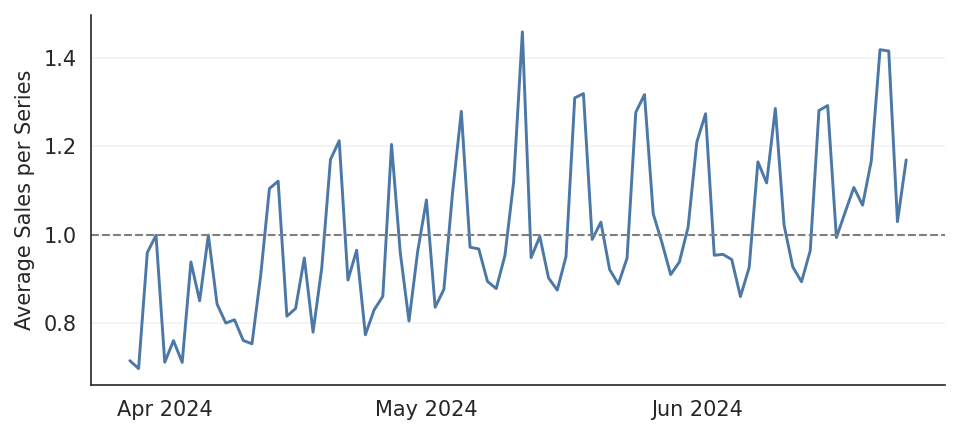

history mean : 0.9986
first 2 weeks: 0.8257
last 2 weeks : 1.127


In [ ]:
# aily sales across the 90 days
import matplotlib.dates as mdates

daily = hist.groupby('ds')['sale_amount'].mean()

fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.plot(daily.index, daily.values, color=RAW, linewidth=1.4)
ax.axhline(daily.mean(), color=GREY, linestyle='--', linewidth=1)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))

ax.set_ylabel('Average Sales per Series')
ax.set_xlabel('')
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_daily_sales.png', dpi=300)
plt.show()

print('history mean :', round(daily.mean(), 4))
print('first 2 weeks:', round(daily.head(14).mean(), 4))
print('last 2 weeks :', round(daily.tail(14).mean(), 4))

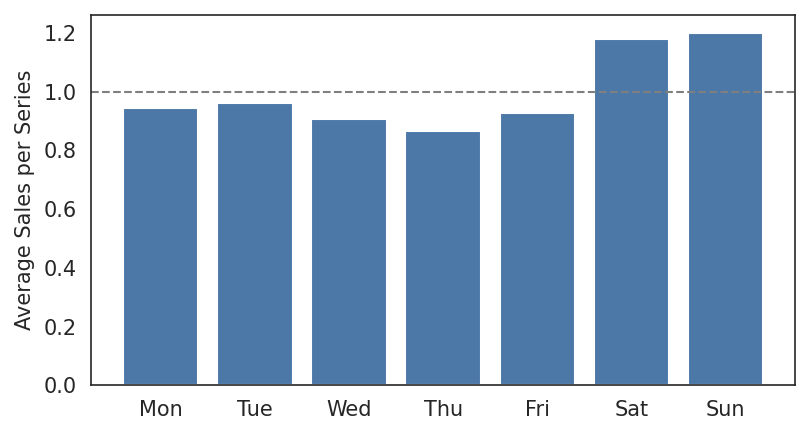

Mon  0.9426   -5.6%
Tue  0.9620   -3.7%
Wed  0.9069   -9.2%
Thu  0.8660   -13.3%
Fri  0.9268   -7.2%
Sat  1.1781   +18.0%
Sun  1.2007   +20.2%


In [ ]:
# average sales by day of week
hist['dow'] = hist['ds'].dt.dayofweek
names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow = hist.groupby('dow')['sale_amount'].mean()

fig, ax = plt.subplots(figsize=(5.5, 3.0))
ax.bar(names, dow.values, color=RAW)
ax.axhline(hist['sale_amount'].mean(), color=GREY, linestyle='--', linewidth=1)
ax.set_ylabel('Average Sales per Series')
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_day_of_week.png', dpi=300)
plt.show()

for i, v in dow.items():
    print(f'{names[i]}  {v:.4f}   {v / hist.sale_amount.mean() - 1:+.1%}')

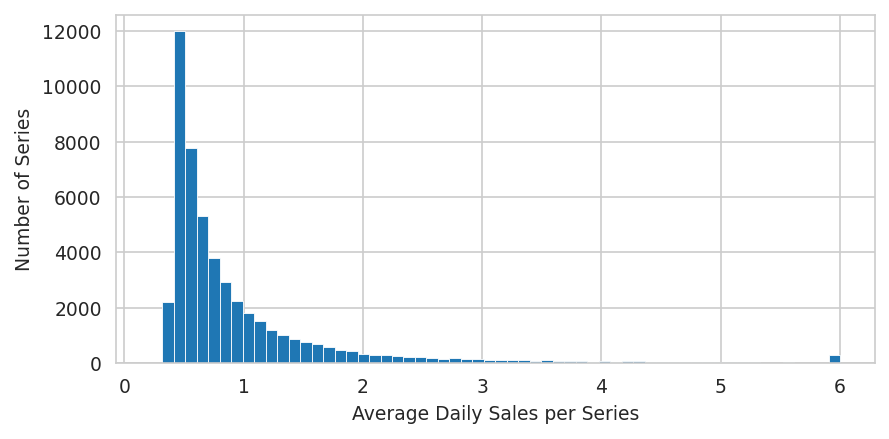

count    50000.000
mean         0.999
std          1.153
min          0.222
5%           0.417
25%          0.494
50%          0.658
75%          1.054
95%          2.651
max         19.074
Name: sale_amount, dtype: float64


In [ ]:
# how many series sell how much
s = hist.groupby(['store_id', 'product_id'])['sale_amount'].mean()

fig, ax = plt.subplots(figsize=(6.0, 3.0))
ax.hist(s.clip(upper=6), bins=60, color=RAW, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Average Daily Sales per Series')
ax.set_ylabel('Number of Series')
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_sales_distribution.png', dpi=300)
plt.show()

print(s.describe(percentiles=[.05, .25, .5, .75, .95]).round(3))

In [ ]:
# descriptive statistics for the seven covariates.

EXOG = ['discount', 'holiday_flag', 'activity_flag', 'precpt',
        'avg_temperature', 'avg_humidity', 'avg_wind_level']

hist = df[df['ds'] <= cf.VAL_END]          # 28 Mar – 25 Jun, 90 days

tbl = (hist[EXOG]
       .agg(['mean', 'std', 'min', 'median', 'max'])
       .T
       .rename(columns={'mean': 'Mean', 'std': 'SD', 'min': 'Minimum',
                        'median': 'Median', 'max': 'Maximum'})
       .round(3))

print(f'{hist.ds.nunique()} days, {len(hist):,} rows')
print(tbl.to_string())

90 days, 4,500,000 rows
                   Mean      SD  Minimum  Median  Maximum
discount          0.911   0.128     0.00   0.989    1.088
holiday_flag      0.344   0.481     0.00   0.000    1.000
activity_flag     0.378   0.477     0.00   0.000    1.000
precpt            3.698   3.678     0.00   2.298   42.500
avg_temperature  22.279   3.589    12.06  22.500   30.880
avg_humidity     74.450  10.087    27.35  76.360  100.000
avg_wind_level    1.725   0.384     0.97   1.640    3.850


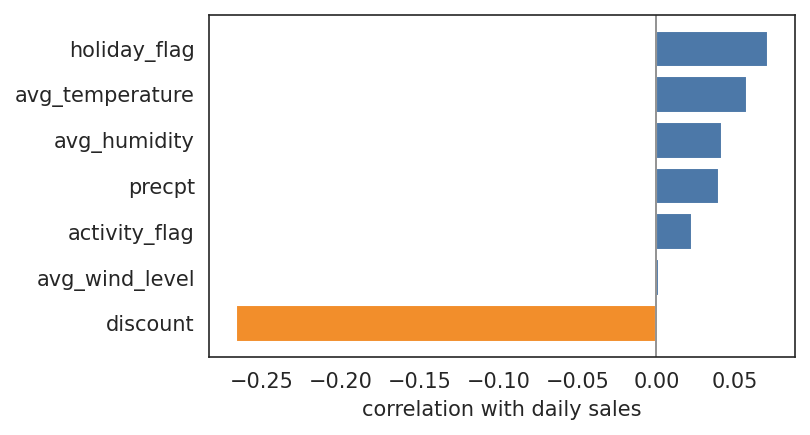

discount          -0.2666
avg_wind_level     0.0018
activity_flag      0.0226
precpt             0.0398
avg_humidity       0.0418
avg_temperature    0.0577
holiday_flag       0.0710


In [ ]:
# which covariates move with sales
clean = hist[hist['stock_hour6_22_cnt'] == 0]
corr = clean[cf.EXOG + ['sale_amount']].corr()['sale_amount'].drop('sale_amount').sort_values()

fig, ax = plt.subplots(figsize=(5.5, 3.0))
ax.barh(corr.index, corr.values, color=[REC if v < 0 else RAW for v in corr.values])
ax.axvline(0, color=GREY, linewidth=0.8)
ax.set_xlabel('correlation with daily sales')
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_covariate_correlation.png', dpi=300)
plt.show()

print(corr.round(4).to_string())

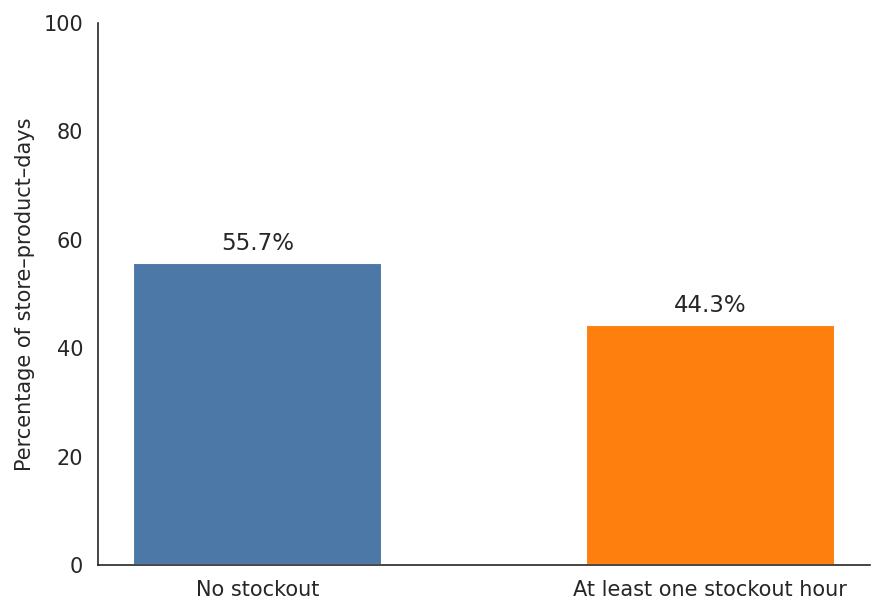

In [ ]:
# share of store-product-days affected by a stockout.

hist = df[df['ds'] <= cf.VAL_END]
share = (hist['stock_hour6_22_cnt'] > 0).mean() * 100

fig, ax = plt.subplots(figsize=(6.0, 4.2))
bars = ax.bar(['No stockout', 'At least one stockout hour'],
              [100 - share, share],
              color=['#4C78A8', '#ff7f0e'], width=0.55)
for b, v in zip(bars, [100 - share, share]):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Percentage of store–product–days')
ax.set_ylim(0, 100)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_stockout_share.png', dpi=300,
            bbox_inches='tight', facecolor='white')

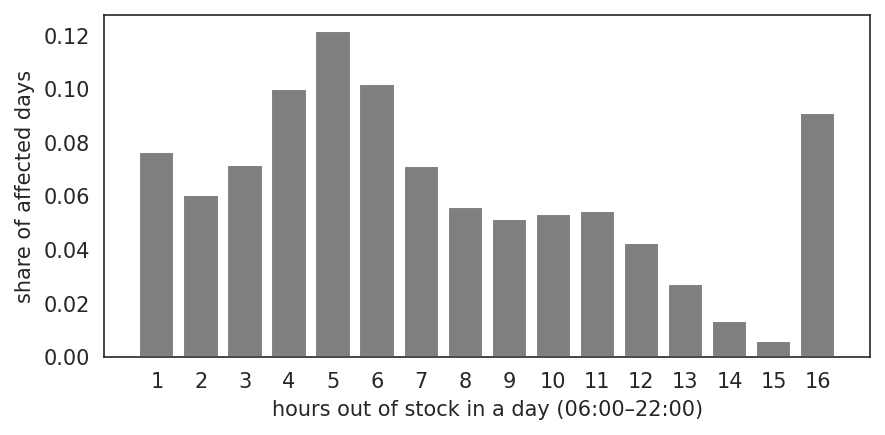

stock_hour6_22_cnt
1.0     0.0765
2.0     0.0604
3.0     0.0716
4.0     0.1002
5.0     0.1216
6.0     0.1021
7.0     0.0714
8.0     0.0561
9.0     0.0515
10.0    0.0536
11.0    0.0546
12.0    0.0424
13.0    0.0271
14.0    0.0134
15.0    0.0061
16.0    0.0913

mean hours on affected days: 7.18


In [ ]:
# how many hours, on days that had a stockout
affected = hist.loc[hist['stock_hour6_22_cnt'] > 0, 'stock_hour6_22_cnt']
dist = affected.value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(6.0, 3.0))
ax.bar(dist.index, dist.values, color=GREY)
ax.set_xlabel('hours out of stock in a day (06:00–22:00)')
ax.set_ylabel('share of affected days')
ax.set_xticks(range(1, 17))
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_stockout_hours.png', dpi=300)
plt.show()

print(dist.round(4).to_string())
print('\nmean hours on affected days:', round(affected.mean(), 2))

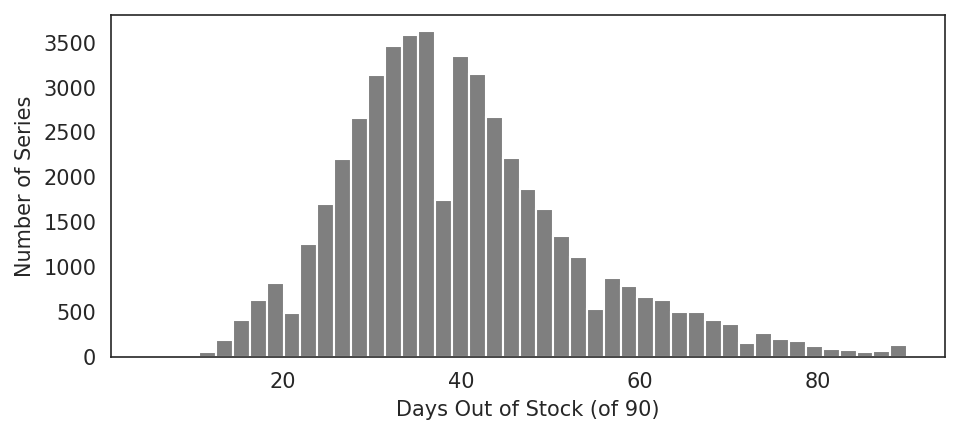

count    50000.0
mean        39.8
std         13.3
min          5.0
25%         31.0
50%         38.0
75%         47.0
max         90.0
Name: stock_hour6_22_cnt, dtype: float64


In [ ]:
# stockout days per series (history only)
so = hist.groupby(['store_id', 'product_id'])['stock_hour6_22_cnt'].apply(lambda x: (x > 0).sum())

plt.figure(figsize=(6.5, 3))
plt.hist(so, bins=45, color=GREY)
plt.xlabel('Days Out of Stock (of 90)')
plt.ylabel('Number of Series')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_stockout_frequency.png', dpi=300)
plt.show()

print(so.describe().round(1))

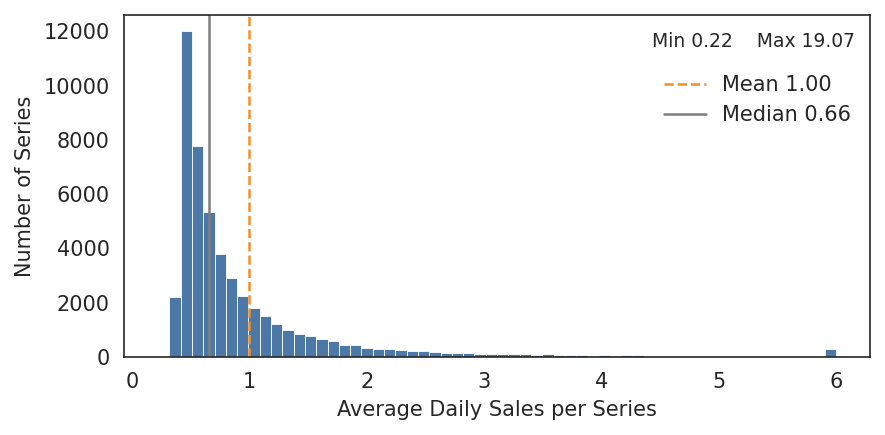

In [ ]:
# how many series sell how much
s = hist.groupby(['store_id', 'product_id'])['sale_amount'].mean()
m, md = s.mean(), s.median()

fig, ax = plt.subplots(figsize=(6.0, 3.0))
ax.hist(s.clip(upper=6), bins=60, color=RAW, edgecolor='white', linewidth=0.4)
ax.axvline(m,  color=REC, linestyle='--', linewidth=1.2, label=f'Mean {m:.2f}')
ax.axvline(md, color=GREY, linestyle='-', linewidth=1.2, label=f'Median {md:.2f}')
ax.text(0.98, 0.95, f'Min {s.min():.2f}    Max {s.max():.2f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9)
ax.set_xlabel('Average Daily Sales per Series')
ax.set_ylabel('Number of Series')
ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.0, 0.88))
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_sales_distribution.png', dpi=300)
plt.show()

In [ ]:
# per-series stockout counts over the full 97-day period
g = df.groupby('unique_id')
so = pd.DataFrame({
    'so_days': g['stock_hour6_22_cnt'].apply(lambda x: (x > 0).sum()),
    'mean_sales': g['sale_amount'].mean(),
})
print('series:', len(so))

series: 50000


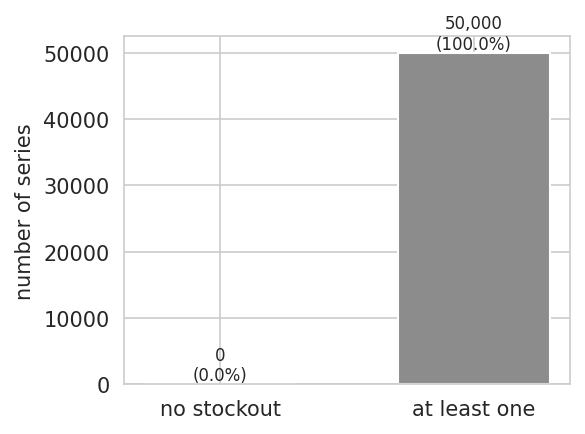

never out of stock : 0 (0.0%)
affected           : 50,000 (100.0%)


In [ ]:
# stockout prevalence
affected = (so['so_days'] > 0).sum()
never = (so['so_days'] == 0).sum()

fig, ax = plt.subplots(figsize=(4.0, 3.0))
ax.bar(['no stockout', 'at least one'], [never, affected], color=[RAW, GREY], width=0.6)
ax.set_ylabel('number of series')
for i, v in enumerate([never, affected]):
    ax.text(i, v, f'{v:,}\n({v / len(so):.1%})', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_stockout_prevalence.png', dpi=300)
plt.show()

print('never out of stock :', f'{never:,}', f'({never / len(so):.1%})')
print('affected           :', f'{affected:,}', f'({affected / len(so):.1%})')

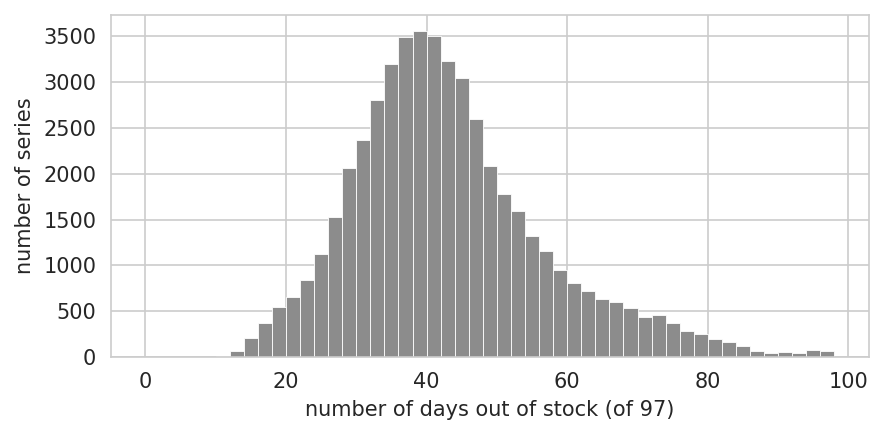

count    50000.0
mean        42.7
std         13.9
min         11.0
5%          23.0
25%         33.0
50%         41.0
75%         50.0
95%         70.0
max         96.0

series with 1-5 stockout days   : 0
series with more than 20 days   : 48466
series with more than 50 days   : 11808


In [ ]:
# distribution of stockout frequency across series
fig, ax = plt.subplots(figsize=(6.0, 3.0))
ax.hist(so['so_days'], bins=range(0, 99, 2), color=GREY, edgecolor='white', linewidth=0.4)
ax.set_xlabel('number of days out of stock (of 97)')
ax.set_ylabel('number of series')
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_stockout_frequency.png', dpi=300)
plt.show()

print(so['so_days'].describe(percentiles=[.05, .25, .5, .75, .95]).round(1).to_string())
print('\nseries with 1-5 stockout days   :', int(so.so_days.between(1, 5).sum()))
print('series with more than 20 days   :', int((so.so_days > 20).sum()))
print('series with more than 50 days   :', int((so.so_days > 50).sum()))

In [ ]:
# does stockout frequency go with sales volume?
bins = pd.cut(so['so_days'], bins=[-1, 0, 10, 20, 30, 40, 60, 97])
print(so.groupby(bins, observed=True)['mean_sales'].agg(['mean', 'median', 'count']).round(3).to_string())
print('\ncorrelation:', round(so['so_days'].corr(so['mean_sales']), 4))

           mean  median  count
so_days                       
(10, 20]  0.850   0.645   1534
(20, 30]  0.787   0.635   7017
(30, 40]  0.818   0.615  16048
(40, 60]  1.110   0.686  19902
(60, 97]  1.563   0.929   5499

correlation: 0.2147


In [ ]:
print(hist['discount'].describe(percentiles=[.05,.25,.5,.75,.95]).round(3))

count    4500000.000
mean           0.911
std            0.128
min            0.000
5%             0.666
25%            0.851
50%            0.989
75%            1.000
95%            1.000
max            1.088
Name: discount, dtype: float64


In [ ]:
# Cell 10 — split the history into censored and uncensored days
cens  = hist[hist['stock_hour6_22_cnt'] > 0]
uncen = hist[hist['stock_hour6_22_cnt'] == 0]

print(f'history rows  {len(hist):,}')
print(f'censored days {len(cens):,} ({len(cens)/len(hist):.1%})')

history rows  4,500,000
censored days 1,992,006 (44.3%)


In [ ]:
# Cell 11 — verification: recovery leaves uncensored days alone and produces no negatives
print('uncensored days, largest change :',
      f"{(uncen['sale_amount_pred'] - uncen['sale_amount']).abs().max():.2e}")
print('negative recovered values       :', int((hist['sale_amount_pred'] < 0).sum()))
print('censored days, recovered < recorded :',
      f"{(cens['sale_amount_pred'] < cens['sale_amount'] - 1e-9).mean():.1%}")

uncensored days, largest change : 3.81e-06
negative recovered values       : 0
censored days, recovered < recorded : 3.8%


In [ ]:
# Cell 12 — how much demand recovery adds
for name, d in [('all history', hist), ('censored days only', cens)]:
    r, p = d['sale_amount'].mean(), d['sale_amount_pred'].mean()
    print(f'{name:20s} recorded {r:.4f}   recovered {p:.4f}   ({p/r-1:+.1%})')

all history          recorded 0.9986   recovered 1.2033   (+20.5%)
censored days only   recorded 1.0289   recovered 1.4913   (+44.9%)


In [ ]:
# Cell 13 — recorded vs recovered demand by number of stockout hours
bins = pd.cut(cens['stock_hour6_22_cnt'], [0, 2, 4, 8, 12, 16])
tab = (cens.groupby(bins, observed=True)
            .agg(days=('sale_amount', 'size'),
                 recorded=('sale_amount', 'mean'),
                 recovered=('sale_amount_pred', 'mean')))
tab['uplift_%'] = (tab['recovered'] / tab['recorded'] - 1) * 100
print(tab.round(3).to_string())

                      days  recorded  recovered    uplift_%
stock_hour6_22_cnt                                         
(0, 2]              272667     1.409      1.427    1.281000
(2, 4]              342204     1.378      1.490    8.183000
(4, 8]              699703     1.151      1.522   32.139999
(8, 12]             402650     0.824      1.524   85.106003
(12, 16]            274782     0.207      1.431  593.067993


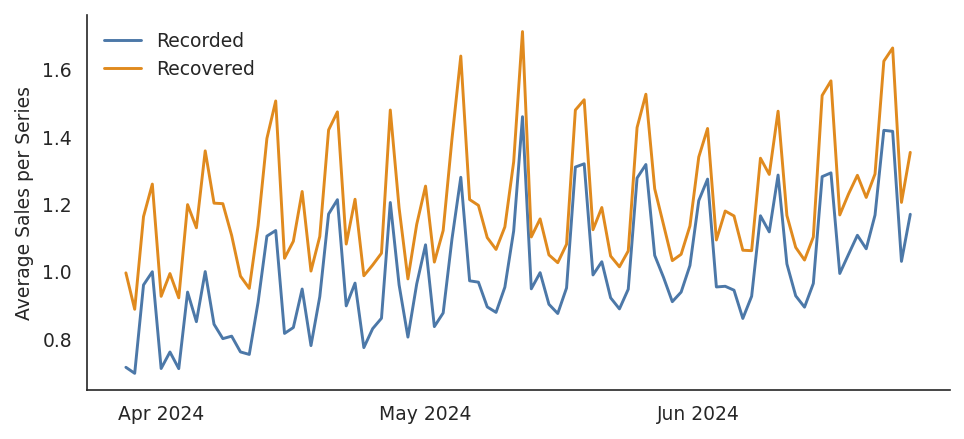

In [ ]:
# daily mean over the 90 days, recorded against recovered
import matplotlib.dates as mdates

ts = hist.groupby('ds')[['sale_amount', 'sale_amount_pred']].mean()

fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.plot(ts.index, ts['sale_amount'], color=RAW, linewidth=1.4, label='Recorded')
ax.plot(ts.index, ts['sale_amount_pred'], color=REC, linewidth=1.4, label='Recovered')

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))

ax.set_ylabel('Average Sales per Series')
ax.set_xlabel('')
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_recovery_timeline.png', dpi=300)
plt.show()

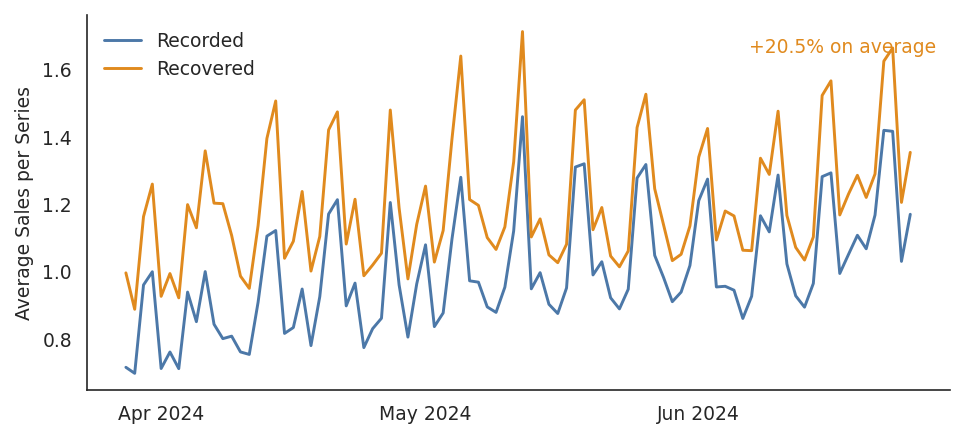

uplift 20.500%


In [ ]:
# daily mean over the 90 days, recorded against recovered
import matplotlib.dates as mdates

ts = hist.groupby('ds')[['sale_amount', 'sale_amount_pred']].mean()
uplift = ts['sale_amount_pred'].mean() / ts['sale_amount'].mean() - 1

fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.plot(ts.index, ts['sale_amount'], color=RAW, linewidth=1.4, label='Recorded')
ax.plot(ts.index, ts['sale_amount_pred'], color=REC, linewidth=1.4, label='Recovered')

ax.annotate(f'+{uplift:.1%} on average', xy=(0.985, 0.94),
            xycoords='axes fraction', ha='right', va='top',
            fontsize=9, color=REC)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))

ax.set_ylabel('Average Sales per Series')
ax.set_xlabel('')
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_recovery_timeline.png', dpi=300)
plt.show()

print(f'uplift {uplift:.3%}')

In [ ]:
# distribution of recovery benefit across series (validation)
fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.hist(w['gain'].clip(-0.5, 0.5), bins=60, color=REC, edgecolor='none')
ax.axvline(0, color=GREY, linestyle='--', linewidth=1)

ax.set_xlabel('Recovery benefit  (WAPE raw − WAPE recovered)')
ax.set_ylabel('Number of Series')
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_recovery_benefit.png', dpi=300)
plt.show()

print(f"helped   : {(w.gain > 0).sum():,} ({(w.gain > 0).mean():.1%})")
print(f"hurt     : {(w.gain < 0).sum():,} ({(w.gain < 0).mean():.1%})")
print(f"median   : {w.gain.median():+.4f}")
print(f"5th, 95th: {w.gain.quantile(.05):+.4f}, {w.gain.quantile(.95):+.4f}")

In [ ]:
# how much recovery added to each series
ser = hist.groupby(['store_id', 'product_id'])[['sale_amount', 'sale_amount_pred']].sum()
uplift = ser['sale_amount_pred'] / ser['sale_amount'] - 1

plt.figure(figsize=(6.5, 3))
plt.hist(uplift, bins=50, range=(0, 1), color=REC)
plt.xlabel('Increase in Demand After Recovery')
plt.ylabel('Number of Series')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_recovery_uplift.png', dpi=300)
plt.show()

print(uplift.describe().round(3))

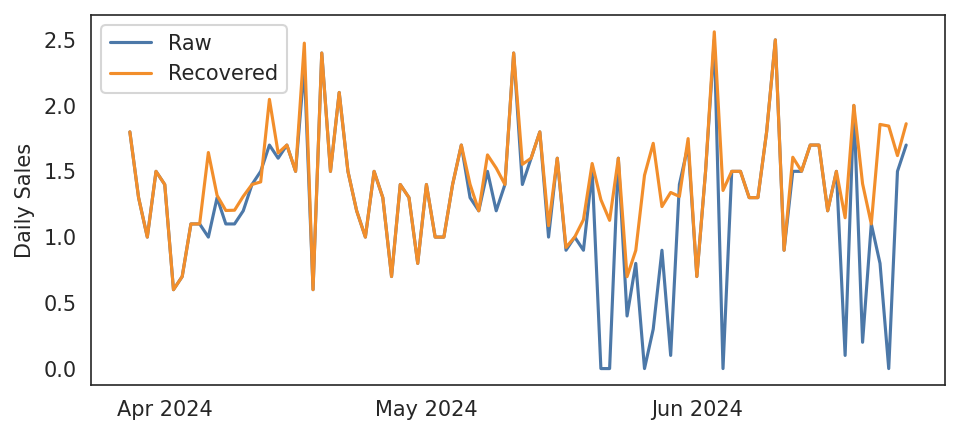

In [ ]:
# one series, recorded and recovered
import matplotlib.dates as mdates

one = hist[(hist.store_id == 322) & (hist.product_id == 666)].sort_values('ds')

plt.figure(figsize=(6.5, 3))
plt.plot(one['ds'], one['sale_amount'], color=RAW, label='Raw')
plt.plot(one['ds'], one['sale_amount_pred'], color=REC, label='Recovered')
plt.ylabel('Daily Sales')
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_series_example.png', dpi=300)
plt.show()

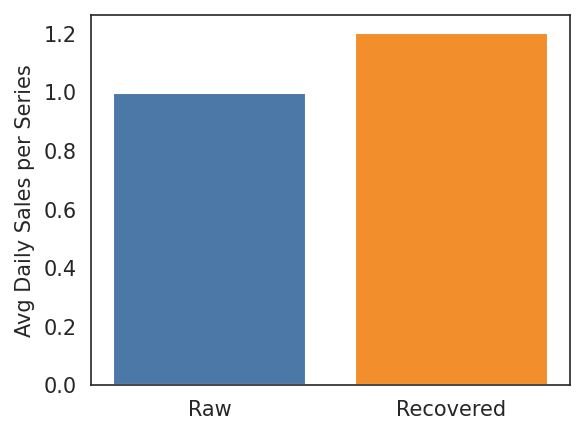

0.9986 -> 1.2033  (+20.5%)


In [ ]:
# average recorded vs recovered demand
means = [hist['sale_amount'].mean(), hist['sale_amount_pred'].mean()]

plt.figure(figsize=(4, 3))
plt.bar(['Raw', 'Recovered'], means, color=[RAW, REC])
plt.ylabel('Avg Daily Sales per Series')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_recovery_average.png', dpi=300)
plt.show()

print(f'{means[0]:.4f} -> {means[1]:.4f}  ({means[1]/means[0]-1:+.1%})')

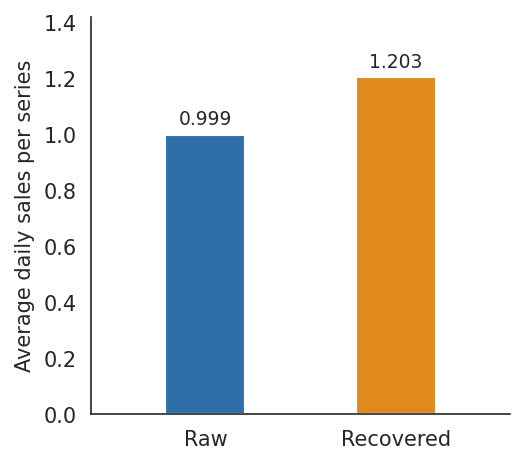

0.9986 -> 1.2033  (+20.5%)


In [ ]:
# average recorded vs recovered demand.

import os
import matplotlib.pyplot as plt

FIGDIR = f'{cf.PROJECT}/figures'
os.makedirs(FIGDIR, exist_ok=True)

hist  = df[df['ds'] <= cf.VAL_END]
means = [hist['sale_amount'].mean(), hist['sale_amount_pred'].mean()]

fig, ax = plt.subplots(figsize=(3.6, 3.2))
bars = ax.bar([0, 1], means, width=0.42,            # was 0.8 by default
              color=['#2f6fa8', '#e08a1e'])
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Raw', 'Recovered'])
ax.set_xlim(-0.6, 1.6)                              # keeps the pair centred
ax.set_ylabel('Average daily sales per series')
ax.set_ylim(0, max(means) * 1.18)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_recovery_average.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f'{means[0]:.4f} -> {means[1]:.4f}  ({means[1]/means[0]-1:+.1%})')

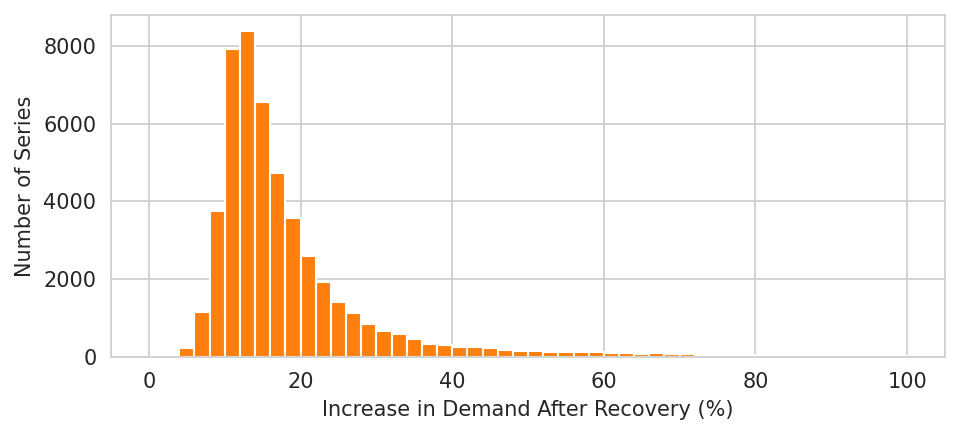

count    50000.0
mean        19.9
std         18.6
min         -4.1
25%         11.9
50%         15.0
75%         20.8
max        504.7
dtype: float64


In [ ]:
# distribution of recovery uplift across series
ser = hist.groupby(['store_id', 'product_id'])[['sale_amount', 'sale_amount_pred']].sum()
uplift = (ser['sale_amount_pred'] / ser['sale_amount'] - 1) * 100

plt.figure(figsize=(6.5, 3))
plt.hist(uplift, bins=50, range=(0, 100), color=REC)
plt.xlabel('Increase in Demand After Recovery (%)')
plt.ylabel('Number of Series')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_recovery_uplift.png', dpi=300)
plt.show()

print(uplift.describe().round(1))

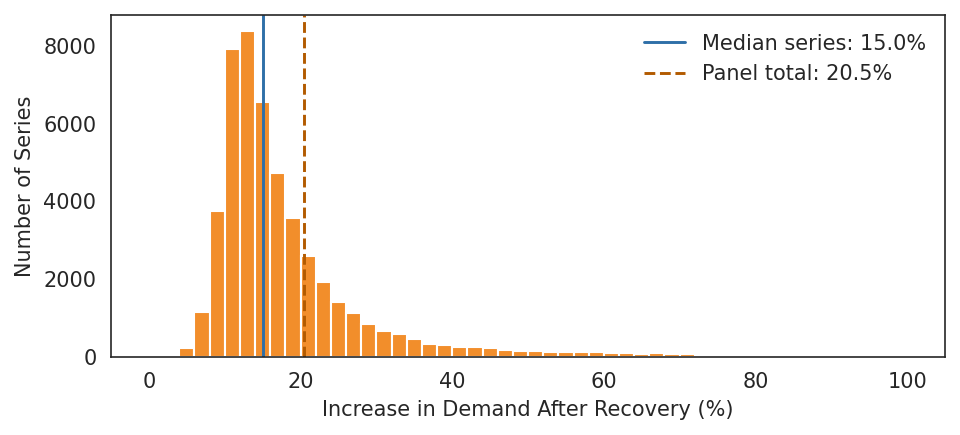

count    50000.0
mean        19.9
std         18.6
min         -4.1
25%         11.9
50%         15.0
75%         20.8
max        504.7
dtype: float64

median 15.0%   panel total 20.5%


In [ ]:
# Cell N — distribution of recovery uplift across series, with the two summaries marked
ser = hist.groupby(['store_id', 'product_id'])[['sale_amount', 'sale_amount_pred']].sum()
uplift = (ser['sale_amount_pred'] / ser['sale_amount'] - 1) * 100

med   = uplift.median()
panel = (ser['sale_amount_pred'].sum() / ser['sale_amount'].sum() - 1) * 100

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(uplift, bins=50, range=(0, 100), color=REC)
ax.axvline(med,   color='#2f6fa8', lw=1.4,
           label=f'Median series: {med:.1f}%')
ax.axvline(panel, color='#b25a00', lw=1.4, ls='--',
           label=f'Panel total: {panel:.1f}%')
ax.set_xlabel('Increase in Demand After Recovery (%)')
ax.set_ylabel('Number of Series')
ax.grid(False)
ax.legend(frameon=False, loc='upper right')
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_recovery_uplift.png', dpi=300)
plt.show()

print(uplift.describe().round(1))
print(f'\nmedian {med:.1f}%   panel total {panel:.1f}%')

In [ ]:
# descriptive statistics for the seven covariates
cols = ['discount', 'holiday_flag', 'activity_flag', 'precpt',
        'avg_temperature', 'avg_humidity', 'avg_wind_level']
print(hist[cols].describe().T[['mean', 'std', 'min', '50%', 'max']].round(3))

                   mean     std    min     50%      max
discount          0.911   0.128   0.00   0.989    1.088
holiday_flag      0.344   0.481   0.00   0.000    1.000
activity_flag     0.378   0.477   0.00   0.000    1.000
precpt            3.698   3.678   0.00   2.298   42.500
avg_temperature  22.279   3.589  12.06  22.500   30.880
avg_humidity     74.450  10.087  27.35  76.360  100.000
avg_wind_level    1.725   0.384   0.97   1.640    3.850


In [ ]:
# what does holiday_flag actually mark?
d = hist.groupby('ds')['holiday_flag'].mean().reset_index()
d['dow'] = d['ds'].dt.day_name()
print('days flagged:', int((d.holiday_flag == 1).sum()), 'of', len(d))
print(d.groupby('dow')['holiday_flag'].mean().round(2).to_string())

days flagged: 31 of 90
dow
Friday       0.15
Monday       0.08
Saturday     1.00
Sunday       0.92
Thursday     0.15
Tuesday      0.00
Wednesday    0.08


In [ ]:
# per-series stockout counts over the 90-day history
g = hist.groupby('unique_id')
so = pd.DataFrame({
    'so_days': g['stock_hour6_22_cnt'].apply(lambda x: (x > 0).sum()),
    'mean_sales': g['sale_amount'].mean(),
})
print('series:', len(so))

series: 50000


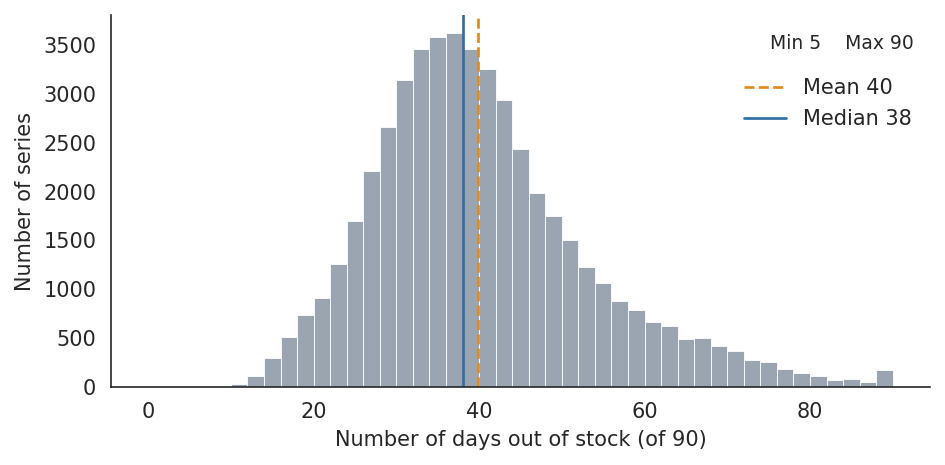

count    50000.0
mean        39.8
std         13.3
min          5.0
25%         31.0
50%         38.0
75%         47.0
max         90.0
Name: out, dtype: float64


In [ ]:
# distribution of stockout frequency across series.

import os
import matplotlib.pyplot as plt

FIGDIR = f'{cf.PROJECT}/figures'
os.makedirs(FIGDIR, exist_ok=True)

hist = df[df['ds'] <= cf.VAL_END]                  # 90-day history

so_days = (hist.assign(out=hist['stock_hour6_22_cnt'] > 0)
               .groupby(['store_id', 'product_id'])['out']
               .sum())

m, md = so_days.mean(), so_days.median()

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.hist(so_days, bins=range(0, 92, 2),
        color='#9aa5b1', edgecolor='white', linewidth=0.4)
ax.axvline(m,  color='#e08a1e', linestyle='--', linewidth=1.3, label=f'Mean {m:.0f}')
ax.axvline(md, color='#2f6fa8', linestyle='-',  linewidth=1.3, label=f'Median {md:.0f}')
ax.text(0.98, 0.95, f'Min {so_days.min():.0f}    Max {so_days.max():.0f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9)

ax.set_xlabel('Number of days out of stock (of 90)')
ax.set_ylabel('Number of series')
ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.0, 0.88))
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_stockout_frequency.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

print(so_days.describe().round(1))

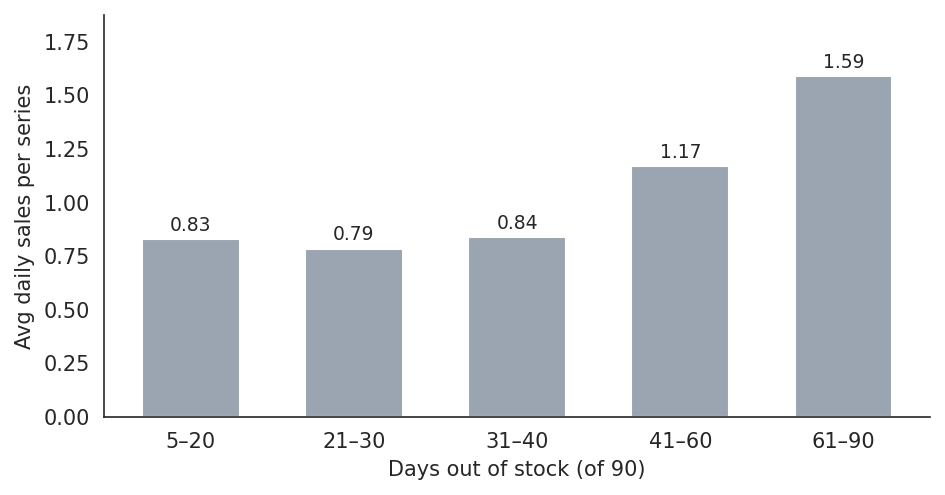

         mean daily sales  series
so_days                          
5–20                 0.83    2134
21–30                0.79    9834
31–40                0.84   17398
41–60                1.17   16566
61–90                1.59    4068


In [ ]:
# average daily sales by number of stockout days

import os
import matplotlib.pyplot as plt

FIGDIR = f'{cf.PROJECT}/figures'
os.makedirs(FIGDIR, exist_ok=True)

hist = df[df['ds'] <= cf.VAL_END]                  # 90-day history

so = (hist.assign(out=hist['stock_hour6_22_cnt'] > 0)
          .groupby(['store_id', 'product_id'])
          .agg(so_days=('out', 'sum'),
               mean_sales=('sale_amount', 'mean')))

bands = pd.cut(so['so_days'], [0, 20, 30, 40, 60, 90],
               labels=['5–20', '21–30', '31–40', '41–60', '61–90'])
avg = so.groupby(bands, observed=True)['mean_sales'].mean()
cnt = so.groupby(bands, observed=True).size()

fig, ax = plt.subplots(figsize=(6.4, 3.4))
bars = ax.bar(avg.index.astype(str), avg.values, color='#9aa5b1', width=0.6)
ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=9)

ax.set_xlabel('Days out of stock (of 90)')
ax.set_ylabel('Avg daily sales per series')
ax.set_ylim(0, avg.max() * 1.18)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_stockout_by_volume.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

print(pd.DataFrame({'mean daily sales': avg.round(2), 'series': cnt}).to_string())

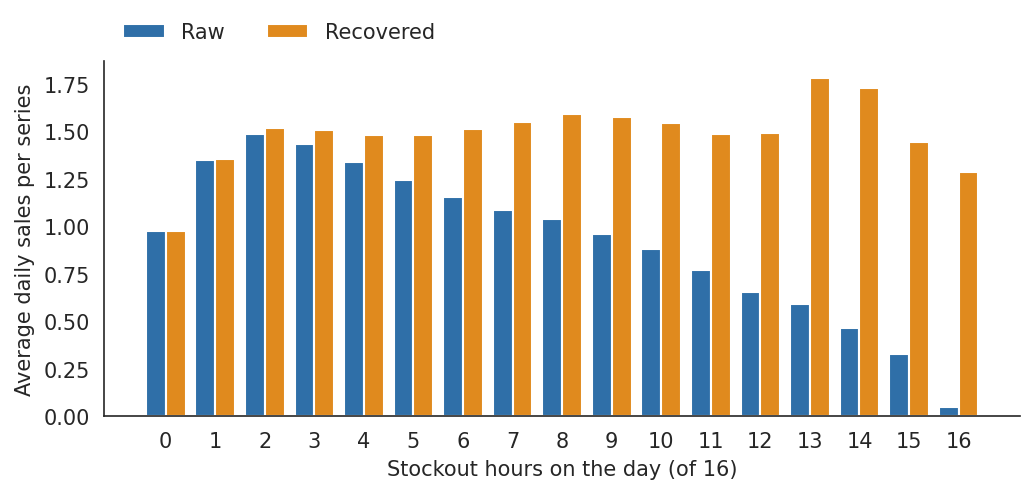

In [ ]:
# recorded demand falls with stockout hours

import os
import matplotlib.pyplot as plt
import numpy as np

FIGDIR = f'{cf.PROJECT}/figures'
os.makedirs(FIGDIR, exist_ok=True)

hist = df[df['ds'] <= cf.VAL_END]

tab = (hist.groupby('stock_hour6_22_cnt')
           .agg(recorded=('sale_amount', 'mean'),
                recovered=('sale_amount_pred', 'mean')))
tab.index = tab.index.astype(int)

x = np.arange(len(tab))
w = 0.4

fig, ax = plt.subplots(figsize=(7.0, 3.4))
ax.bar(x - w/2, tab['recorded'],  w, color='#2f6fa8', label='Raw')
ax.bar(x + w/2, tab['recovered'], w, color='#e08a1e', label='Recovered')

ax.set_xticks(x)
ax.set_xticklabels(tab.index)
ax.set_xlabel('Stockout hours on the day (of 16)')
ax.set_ylabel('Average daily sales per series')

ax.legend(frameon=False, ncol=2,
          loc='lower left', bbox_to_anchor=(0, 1.0))   # sits above the panel

for side in ('top', 'right'):
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_recovery_by_hours.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

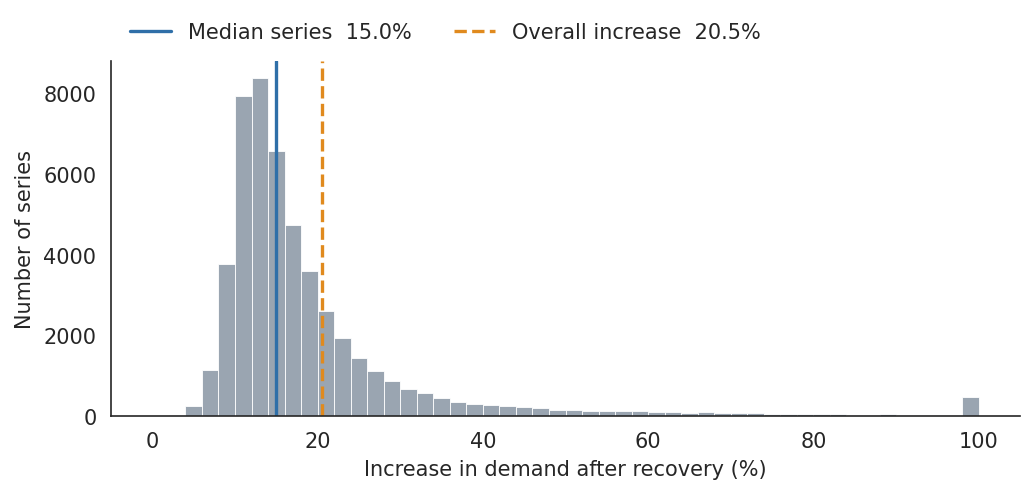

median 15.0%   panel 20.5%   >100%: 448   max 505%


In [ ]:
# increase in demand after recovery, across the 50,000 series.

import os
import matplotlib.pyplot as plt

FIGDIR = f'{cf.PROJECT}/figures'
os.makedirs(FIGDIR, exist_ok=True)

hist = df[df['ds'] <= cf.VAL_END]
g = (hist.groupby(['store_id', 'product_id'])
         .agg(rec=('sale_amount', 'mean'), rcv=('sale_amount_pred', 'mean')))

uplift = (g.rcv / g.rec - 1) * 100
med    = uplift.median()
panel  = (g.rcv.sum() / g.rec.sum() - 1) * 100
beyond = int((uplift > 100).sum())

fig, ax = plt.subplots(figsize=(7.0, 3.4))
ax.hist(uplift.clip(upper=100), bins=range(0, 102, 2),
        color='#9aa5b1', edgecolor='white', linewidth=0.4)

ax.axvline(med,   color='#2f6fa8', lw=1.6, label=f'Median series  {med:.1f}%')
ax.axvline(panel, color='#e08a1e', lw=1.6, ls='--', label=f'Overall increase  {panel:.1f}%')
ax.set_xlabel('Increase in demand after recovery (%)')
ax.set_ylabel('Number of series')
ax.legend(frameon=False, ncol=2, loc='lower left', bbox_to_anchor=(0, 1.0))
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_recovery_uplift.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f'median {med:.1f}%   panel {panel:.1f}%   >100%: {beyond}   max {uplift.max():.0f}%')

In [ ]:
# Cell N — library versions for Table 3.9.
import importlib.metadata as md

for pkg in ['neuralforecast', 'mlforecast', 'statsforecast', 'optuna',
            'lightgbm', 'matplotlib', 'seaborn',
            'pandas', 'numpy', 'pyarrow', 'scikit-learn', 'torch']:
    try:
        print(f'{pkg:16s} {md.version(pkg)}')
    except md.PackageNotFoundError:
        print(f'{pkg:16s} not installed')

neuralforecast   not installed
mlforecast       not installed
statsforecast    not installed
optuna           not installed
lightgbm         4.6.0
matplotlib       3.10.0
seaborn          0.13.2
pandas           2.2.3
numpy            2.1.3
pyarrow          18.1.0
scikit-learn     1.6.1
torch            2.11.0+cpu


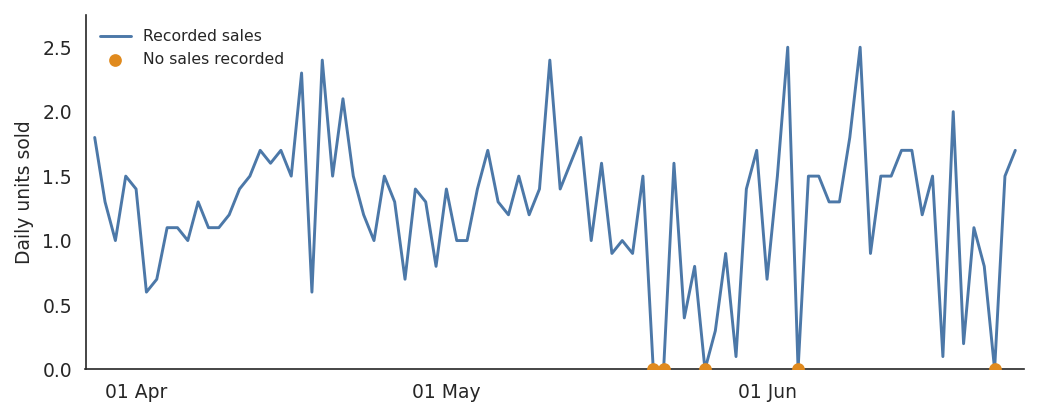

90 days plotted
        ds  sale_amount  stock_hour6_22_cnt
2024-05-21          0.0                16.0
2024-05-22          0.0                16.0
2024-05-26          0.0                16.0
2024-06-04          0.0                16.0
2024-06-23          0.0                16.0


In [ ]:
# Cell N — one series: recorded sales, with the no-sale days marked
import matplotlib.dates as mdates

STORE, PRODUCT = 322, 666

g = hist[(hist['store_id'] == STORE) &
         (hist['product_id'] == PRODUCT)].sort_values('ds')

z = g[g['sale_amount'] == 0]

fig, ax = plt.subplots(figsize=(7.0, 2.85))
ax.plot(g['ds'], g['sale_amount'], color=RAW, lw=1.4, zorder=2,
        label='Recorded sales')
ax.scatter(z['ds'], z['sale_amount'], s=26, color=REC, zorder=3,
           label='No sales recorded')
ax.legend(frameon=False, fontsize=7.5, loc='upper left')

ax.set_ylabel('Daily units sold')
ax.set_ylim(0, g['sale_amount'].max() * 1.10)
ax.margins(x=0.01)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.grid(False)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.tick_params(length=3)

fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_one_series_censoring.png', dpi=300)
plt.show()

print(len(g), 'days plotted')
print(g.loc[g['sale_amount'] == 0, ['ds', 'sale_amount', 'stock_hour6_22_cnt']]
      .to_string(index=False))

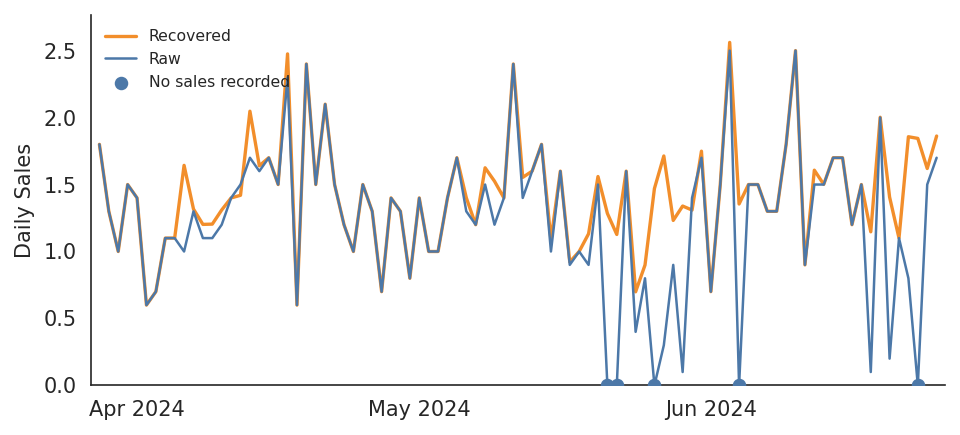

In [ ]:
# one series, recorded and recovered
import matplotlib.dates as mdates

one = hist[(hist.store_id == 322) & (hist.product_id == 666)].sort_values('ds')
zero = one[one['sale_amount'] == 0]

plt.figure(figsize=(6.5, 3))
plt.plot(one['ds'], one['sale_amount_pred'], color=REC, lw=1.6, label='Recovered')
plt.plot(one['ds'], one['sale_amount'], color=RAW, lw=1.2, label='Raw')
plt.scatter(zero['ds'], [0] * len(zero), s=30, color=RAW, zorder=5,
            label='No sales recorded')
plt.ylabel('Daily Sales')
plt.legend(frameon=False, fontsize=7.5, loc='upper left')

ax = plt.gca()
ax.set_ylim(0, one['sale_amount_pred'].max() * 1.08)
ax.margins(x=0.01)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(False)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_series_example.png', dpi=300)
plt.show()